## Setup

In [13]:
import numpy as np

In [14]:
!uv add numpy

Resolved 85 packages in 28ms
Audited 72 packages in 21ms
Audited 72 packages in 21ms


# Load Indian Face Dataset

This notebook cell loads images from `data/Indian_Face_Dataset/IMFDB FR dataset/IMFDB FR dataset/` — traversing each person folder, reading image files, and collecting labels and paths. It prints a brief summary and displays a few samples. If you need a different path, update `base_dir` accordingly.

## Explore Dataset Structure

In [15]:
from pathlib import Path

base_dir = Path('/Users/admin/ds_course/data_science/datascience_assignments/ml_project/data/Indian_Face_Dataset')

# See what's directly inside
for item in sorted(base_dir.iterdir()):
    print(item.name, "— is folder:", item.is_dir())

IMFDB FR dataset — is folder: True
actors list.txt — is folder: False
 — is folder: True
actors list.txt — is folder: False


In [16]:
# Go one level deeper
for item in sorted(base_dir.iterdir()):
    if item.is_dir():
        print(f"\n📁 {item.name}/")
        for sub in list(item.iterdir())[:5]:  # first 5 items inside
            print(f"   {sub.name}")


📁 IMFDB FR dataset/
   IMFDB FR dataset


## Exploratory Data Analysis (EDA)

Loaded 34513 images from 100 identities.
Top 5 identities by image count: [('Soundarya', 620), ('RajeshKhanna', 592), ('Brahmanandam', 574), ('MadhuriDixit', 548), ('AamairKhan', 540)]


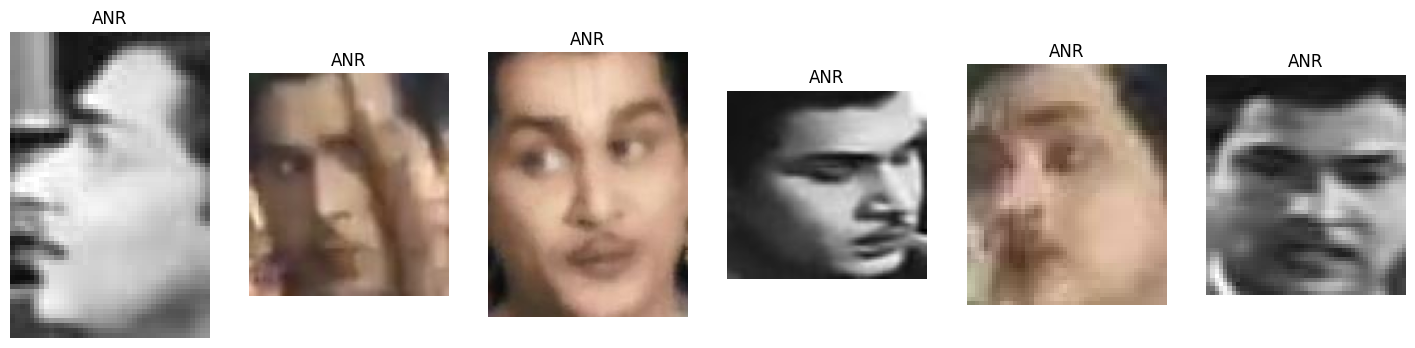

In [17]:
from pathlib import Path
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from collections import Counter

# Adjust this path if your dataset is located elsewhere
base_dir = Path('/Users/admin/ds_course/data_science/datascience_assignments/ml_project/data/Indian_Face_Dataset/IMFDB FR dataset/IMFDB FR dataset')
if not base_dir.exists():
    raise FileNotFoundError(f"Dataset directory not found: {base_dir.resolve()}")

def load_images(base_dir, extensions=('jpg','jpeg','png')):
    images = []
    labels = []
    paths = []
    for person_dir in sorted(base_dir.iterdir()):
        if not person_dir.is_dir():
            continue
        label = person_dir.name
        for img_path in person_dir.rglob('*'):
            if img_path.suffix.lower().lstrip('.') in extensions:
                try:
                    img = Image.open(img_path).convert('RGB')
                    images.append(np.array(img))
                    labels.append(label)
                    paths.append(str(img_path))
                except Exception as e:
                    # keep going if any file is unreadable
                    print(f'Failed to read {img_path}: {e}')
    return images, labels, paths

images, labels, paths = load_images(base_dir)
print(f'Loaded {len(images)} images from {len(set(labels))} identities.')

# Show top identities by image count
cnt = Counter(labels)
print('Top 5 identities by image count:', cnt.most_common(5))

# Display a few sample images (if available)
n = min(6, len(images))
if n > 0:
    fig, axes = plt.subplots(1, n, figsize=(3*n, 4))
    for i in range(n):
        ax = axes[i] if n > 1 else axes
        ax.imshow(images[i])
        ax.axis('off')
        ax.set_title(labels[i])
    plt.show()
else:
    print('No images found to display.')

# If you'd like to convert to arrays with a fixed size, resize here before storing

In [18]:
# Check actors with LEAST images
print("Bottom 10 actors by image count:")
for actor, count in cnt.most_common()[:-11:-1]:
    print(f"  {actor}: {count} images")

# Check image size variety
print("\nSample image shapes:")
for i in range(0, 15):
    print(f"  {labels[i]}: {images[i].shape}")

Bottom 10 actors by image count:
  Rimisen: 200 images
  MadhabiMukherjee: 200 images
  NedumudiVenu: 202 images
  Mallikarjunrao: 204 images
  KarunaBenerjee: 214 images
  SailendraMukherjee: 215 images
  SoumithraChatterjee: 216 images
  Pavithralokesh: 217 images
  BomanIrani: 218 images
  Lakshmidevi: 219 images

Sample image shapes:
  ANR: (63, 41, 3)
  ANR: (94, 84, 3)
  ANR: (194, 146, 3)
  ANR: (68, 72, 3)
  ANR: (58, 48, 3)
  ANR: (52, 47, 3)
  ANR: (128, 78, 3)
  ANR: (172, 130, 3)
  ANR: (54, 44, 3)
  ANR: (139, 143, 3)
  ANR: (126, 96, 3)
  ANR: (106, 90, 3)
  ANR: (111, 93, 3)
  ANR: (211, 149, 3)
  ANR: (207, 153, 3)


## Image Size Distribution

Height — min: 11, max: 964, avg: 128
Width  — min: 8,  max: 852,  avg: 101

Images smaller than 50px in any dimension: 10457


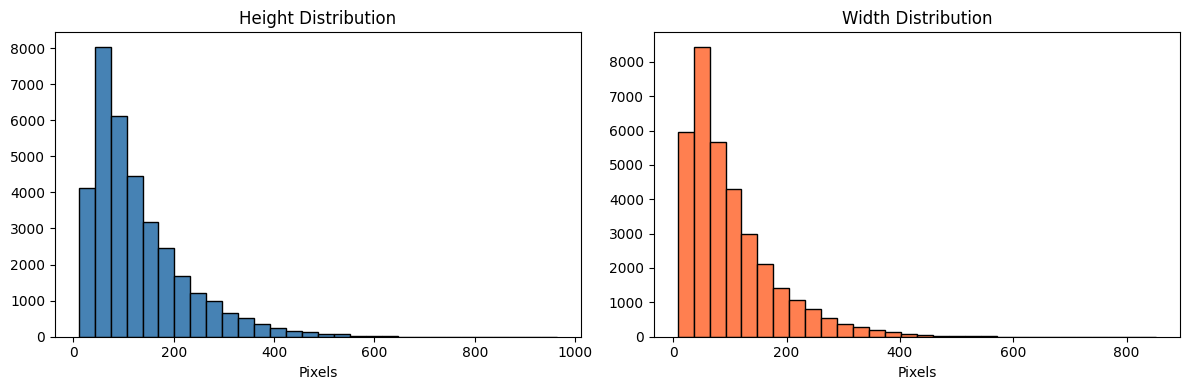

In [19]:
# Check size distribution
heights = [img.shape[0] for img in images]
widths  = [img.shape[1] for img in images]

print(f"Height — min: {min(heights)}, max: {max(heights)}, avg: {int(np.mean(heights))}")
print(f"Width  — min: {min(widths)},  max: {max(widths)},  avg: {int(np.mean(widths))}")

# How many images are very small (might be too low quality)
too_small = sum(1 for h, w in zip(heights, widths) if h < 50 or w < 50)
print(f"\nImages smaller than 50px in any dimension: {too_small}")

# Plot size distribution
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(heights, bins=30, color='steelblue', edgecolor='black')
plt.title("Height Distribution")
plt.xlabel("Pixels")

plt.subplot(1, 2, 2)
plt.hist(widths, bins=30, color='coral', edgecolor='black')
plt.title("Width Distribution")
plt.xlabel("Pixels")

plt.tight_layout()
plt.show()

## Filter Low-Quality Images

In [20]:
# Check how many images survive the filter
MIN_SIZE = 50

filtered_images = []
filtered_labels = []
filtered_paths  = []

for img, label, path in zip(images, labels, paths):
    h, w = img.shape[0], img.shape[1]
    if h >= MIN_SIZE and w >= MIN_SIZE:
        filtered_images.append(img)
        filtered_labels.append(label)
        filtered_paths.append(path)

print(f"Before filtering : {len(images)} images")
print(f"After filtering  : {len(filtered_images)} images")
print(f"Removed          : {len(images) - len(filtered_images)} images")

# Check per-actor counts after filtering
from collections import Counter
filtered_cnt = Counter(filtered_labels)

print(f"\nUnique actors after filtering: {len(filtered_cnt)}")
print(f"Min images per actor: {min(filtered_cnt.values())} — {min(filtered_cnt, key=filtered_cnt.get)}")
print(f"Max images per actor: {max(filtered_cnt.values())} — {max(filtered_cnt, key=filtered_cnt.get)}")

# Any actor drop below 50 images after filtering?
low_data = {k: v for k, v in filtered_cnt.items() if v < 50}
if low_data:
    print(f"\n⚠️ Actors below 50 images after filtering:")
    for actor, count in sorted(low_data.items(), key=lambda x: x[1]):
        print(f"   {actor}: {count}")
else:
    print("\n✅ All actors still have 50+ images after filtering")

Before filtering : 34513 images
After filtering  : 24056 images
Removed          : 10457 images

Unique actors after filtering: 100
Min images per actor: 25 — Balakrishna
Max images per actor: 514 — AamairKhan

⚠️ Actors below 50 images after filtering:
   Balakrishna: 25
   Lakshmidevi: 32


## Resize Images to 160×160

In [21]:
from PIL import Image as PILImage
import numpy as np

TARGET_SIZE = (160, 160)

resized_images = []

for img in filtered_images:
    pil_img = PILImage.fromarray(img)
    pil_img = pil_img.resize(TARGET_SIZE, PILImage.BILINEAR)
    resized_images.append(np.array(pil_img))

resized_images = np.array(resized_images)

print(f"Resized dataset shape : {resized_images.shape}")
print(f"Expected              : (24056, 160, 160, 3)")
print(f"Min pixel value       : {resized_images.min()}")
print(f"Max pixel value       : {resized_images.max()}")

Resized dataset shape : (24056, 160, 160, 3)
Expected              : (24056, 160, 160, 3)
Min pixel value       : 0
Max pixel value       : 255
Min pixel value       : 0
Max pixel value       : 255


## Save Processed Images to Disk

In [23]:
import os
from PIL import Image as PILImage
from pathlib import Path

TARGET_SIZE = (160, 160)
SAVE_DIR = Path("data/processed")

# Create one folder per actor
for label in set(filtered_labels):
    (SAVE_DIR / label).mkdir(parents=True, exist_ok=True)

# Resize and save each image to disk
failed = 0
for img, label, path in zip(filtered_images, filtered_labels, filtered_paths):
    try:
        pil_img = PILImage.fromarray(img)
        pil_img = pil_img.resize(TARGET_SIZE, PILImage.BILINEAR)
        
        filename = Path(path).name
        save_path = SAVE_DIR / label / filename
        pil_img.save(str(save_path))
    except Exception as e:
        failed += 1

print(f"Saved to disk : {SAVE_DIR}")
print(f"Failed        : {failed}")

# Verify
total_saved = sum(len(os.listdir(SAVE_DIR / label)) for label in os.listdir(SAVE_DIR))
print(f"Total images saved : {total_saved}")

Saved to disk : data/processed
Failed        : 0
Total images saved : 24056


## Train / Val / Test Split

In [24]:
import os
import shutil
import random
from pathlib import Path

SOURCE_DIR = Path("data/processed")
OUTPUT_DIR = Path("data/splits")

TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

random.seed(42)  # for reproducibility

train_count = val_count = test_count = 0

for actor in os.listdir(SOURCE_DIR):
    actor_dir = SOURCE_DIR / actor
    if not actor_dir.is_dir():
        continue

    images = os.listdir(actor_dir)
    random.shuffle(images)

    n = len(images)
    n_train = int(n * TRAIN_RATIO)
    n_val   = int(n * VAL_RATIO)

    train_imgs = images[:n_train]
    val_imgs   = images[n_train:n_train + n_val]
    test_imgs  = images[n_train + n_val:]

    for split, split_imgs in [("train", train_imgs), ("val", val_imgs), ("test", test_imgs)]:
        dest = OUTPUT_DIR / split / actor
        dest.mkdir(parents=True, exist_ok=True)
        for img_file in split_imgs:
            shutil.copy(actor_dir / img_file, dest / img_file)

    train_count += len(train_imgs)
    val_count   += len(val_imgs)
    test_count  += len(test_imgs)

print(f"Train images : {train_count}")
print(f"Val images   : {val_count}")
print(f"Test images  : {test_count}")
print(f"Total        : {train_count + val_count + test_count}")
print(f"\n✅ Splits saved to: {OUTPUT_DIR}")

Train images : 16794
Val images   : 3562
Test images  : 3700
Total        : 24056

✅ Splits saved to: data/splits


## 🧠 MTCNN Face Detection & Cropping

This is the preprocessing step actually used to build the dataset for model training (see `02_model_training_demo.ipynb`). For every image:

- Run **MTCNN** face detection
- Keep the highest-confidence face (must be ≥ 0.90 confidence, otherwise skip)
- Crop with a 20% margin around the detected box
- Resize to 160×160
- Save to `data/mtcnn_processed/<actor>/`

This produces the face-aligned dataset that gets split below and zipped for training in Colab.

In [ ]:
import os
import cv2
import numpy as np
from pathlib import Path
from mtcnn import MTCNN
from PIL import Image

SOURCE_DIR = Path('/Users/admin/ds_course/data_science/datascience_assignments/ml_project/data/Indian_Face_Dataset/IMFDB FR dataset/IMFDB FR dataset')
OUTPUT_DIR = Path('/Users/admin/ds_course/data_science/datascience_assignments/ml_project/data/mtcnn_processed')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET_SIZE = (160, 160)
detector    = MTCNN()

total_saved  = 0
total_failed = 0
no_face      = 0

actors = sorted([a for a in os.listdir(SOURCE_DIR) if (SOURCE_DIR / a).is_dir()])
print(f"Processing {len(actors)} actors...\n")

for i, actor in enumerate(actors):
    actor_dir     = SOURCE_DIR / actor
    out_actor_dir = OUTPUT_DIR / actor
    out_actor_dir.mkdir(exist_ok=True)

    actor_saved = 0

    for img_file in os.listdir(actor_dir):
        if not img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue

        img_path = actor_dir / img_file
        try:
            img = cv2.imread(str(img_path))
            if img is None:
                total_failed += 1
                continue

            img_rgb    = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            detections = detector.detect_faces(img_rgb)

            if len(detections) == 0:
                no_face += 1
                continue

            best = max(detections, key=lambda x: x['confidence'])

            if best['confidence'] < 0.90:
                no_face += 1
                continue

            x, y, w, h = best['box']
            margin = int(0.2 * max(w, h))
            x1 = max(0, x - margin)
            y1 = max(0, y - margin)
            x2 = min(img_rgb.shape[1], x + w + margin)
            y2 = min(img_rgb.shape[0], y + h + margin)

            face     = img_rgb[y1:y2, x1:x2]
            face_pil = Image.fromarray(face).resize(TARGET_SIZE, Image.BILINEAR)

            face_pil.save(str(out_actor_dir / img_file))
            actor_saved  += 1
            total_saved  += 1

        except Exception:
            total_failed += 1

    print(f"[{i+1:3d}/100] {actor:<30} → {actor_saved} faces saved")

print(f"\n{'='*50}")
print(f"Total saved      : {total_saved}")
print(f"No face found    : {no_face}")
print(f"Failed (error)   : {total_failed}")
print(f"Detection rate   : {total_saved/(total_saved+no_face+total_failed)*100:.1f}%")

## Train/Val/Test Split (MTCNN-processed data)

Splits the MTCNN-cropped faces 70/15/15 into `data/mtcnn_splits/{train,val,test}/<actor>/`. This is the dataset zipped (`mtcnn_splits.zip`) and used for training/evaluation in `02_model_training_demo.ipynb`.

In [ ]:
import os
import shutil
import random
from pathlib import Path

SOURCE_DIR = Path('/Users/admin/ds_course/data_science/datascience_assignments/ml_project/data/mtcnn_processed')
OUTPUT_DIR = Path('/Users/admin/ds_course/data_science/datascience_assignments/ml_project/data/mtcnn_splits')

TRAIN_RATIO, VAL_RATIO = 0.70, 0.15
random.seed(42)
train_count = val_count = test_count = 0

for actor in os.listdir(SOURCE_DIR):
    actor_dir = SOURCE_DIR / actor
    if not actor_dir.is_dir():
        continue
    images = os.listdir(actor_dir)
    random.shuffle(images)
    n       = len(images)
    n_train = int(n * TRAIN_RATIO)
    n_val   = int(n * VAL_RATIO)
    for split, imgs in [('train', images[:n_train]),
                        ('val',   images[n_train:n_train+n_val]),
                        ('test',  images[n_train+n_val:])]:
        dest = OUTPUT_DIR / split / actor
        dest.mkdir(parents=True, exist_ok=True)
        for f in imgs:
            shutil.copy(actor_dir / f, dest / f)
    train_count += n_train
    val_count   += n_val
    test_count  += n - n_train - n_val

print(f"Train : {train_count}")
print(f"Val   : {val_count}")
print(f"Test  : {test_count}")
print(f"Total : {train_count + val_count + test_count}")
print("Splits saved to data/mtcnn_splits ✅")

## Verify MTCNN Processed Dataset

In [25]:
from pathlib import Path
from collections import Counter
import os

OUTPUT_DIR = Path('/Users/admin/ds_course/data_science/datascience_assignments/ml_project/data/mtcnn_processed')

actor_counts = {}
for actor in os.listdir(OUTPUT_DIR):
    actor_dir = OUTPUT_DIR / actor
    if actor_dir.is_dir():
        actor_counts[actor] = len(os.listdir(actor_dir))

print(f"Total actors : {len(actor_counts)}")
print(f"Min images   : {min(actor_counts.values())} — {min(actor_counts, key=actor_counts.get)}")
print(f"Max images   : {max(actor_counts.values())} — {max(actor_counts, key=actor_counts.get)}")

# Flag anyone below 30
low = {k:v for k,v in actor_counts.items() if v < 30}
if low:
    print(f"\n⚠️ Actors below 30 images:")
    for actor, count in sorted(low.items(), key=lambda x: x[1]):
        print(f"   {actor}: {count}")
else:
    print("\n✅ All actors have 30+ images")


Total actors : 100
Min images   : 90 — K.Viswanath
Max images   : 499 — RajeshKhanna

✅ All actors have 30+ images


## Final Split Summary

In [26]:
print(f"Train : {train_count}")
print(f"Val   : {val_count}")
print(f"Test  : {test_count}")
print(f"Total : {train_count + val_count + test_count}")

Train : 16794
Val   : 3562
Test  : 3700
Total : 24056
